In [1]:
import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as stats

from magi import MAGI
import blackjax

import pandas as pd
import time

In [2]:
tau = [jnp.linspace(0, 20, 41),
       jnp.linspace(0, 20, 41)]

hyperparameters = {
    "theta" : jnp.array([0.2, 0.2, 3.0]),
    "X0" : jnp.array([-1.0, 1.0]),
    "sigma" : jnp.array([0.2, 0.2]),
    "tau" : tau,
    # "obs_times" : test_helpers.obs_matrix(tau),
    "I" : jnp.linspace(0, 20, int(160 +1))
}

def ode(X, theta, t=None):
    '''
    X : n x D
    theta : p

    return : n x D
    '''
    n = X.shape[0]
    V, R = X.T
    a, b, c = theta # theta.repeat([n, 1]).T

    return jnp.stack([c * (V - V**3/3 + R),
                        -1/c * (V - a + b*R)])

In [3]:
data = pd.read_csv('y.csv', header=None).to_numpy()
I = np.arange(0, 20.1, 0.125)
full = np.full((I.shape[0], data.shape[1]), np.nan)
full[:,0] = I
full[np.isin(full[:,0], data[:,0])] = data

# full[:,2] = np.nan
# pd.DataFrame(full).to_csv('y_disc.csv', index=False)

In [4]:
dtype = jnp.float32

start = time.time()
solver = MAGI(ode, full, [1, 1, 1], theta_conf=[0,0,0], sigmas=[0.2, 0.2])

solver.put(dtype, jax.devices()[0])
end = time.time()
print(f"Initialization time: {end - start:.4f}")

# start = time.time()
# solver.solve(k=200, sigma_init=0.01, mitosis_splits=2, optimizer_kwargs={'learning_rate': 0.01}, atol=0.1, rtol=0, max_iter=100)
# end = time.time()
# print(f"Elapsed time: {end - start:.4f}")

Initialization time: 4.8809


In [5]:
solver.put(device=jax.devices('cpu')[0])

In [6]:
with jax.default_device(jax.devices('cpu')[0]):
    start = time.time()
    Xs, thetas, sigmas = jax.block_until_ready(solver.nuts())
    end = time.time()
    print(f"Sampling time: {end - start:.4f}")

Sampling time: 48.6518


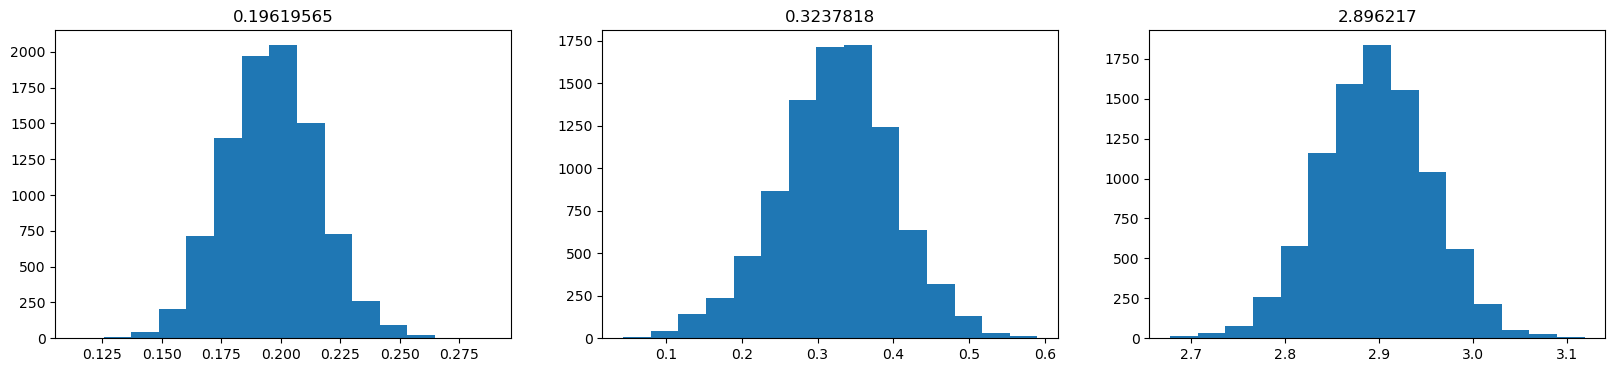

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i in range(3):
    ax[i].hist(thetas[:,i], bins=15)
    ax[i].set_title(thetas[:,i].mean())

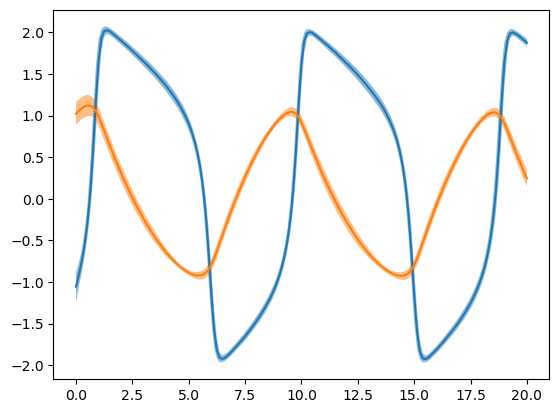

In [8]:
plt.fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,0], 0.025, axis=0), jnp.quantile(Xs[:,:,0], 0.975, axis=0), alpha=0.5)
plt.plot(solver.I, Xs.mean(axis=0)[:,0])

plt.fill_between(solver.I.flatten(), jnp.quantile(Xs[:,:,1], 0.025, axis=0), jnp.quantile(Xs[:,:,1], 0.975, axis=0), alpha=0.5)
plt.plot(solver.I, Xs.mean(axis=0)[:,1])